# Store Sales Forecasting — LightGBM Time Series

Predicting daily sales across **54 stores** and **33 product families** using LightGBM with feature engineering: lag features, rolling averages, holiday flags, oil prices, and store metadata.

**Dataset:** Corporación Favorita (Ecuador retail chain) | **Target:** daily `sales` | **Metric:** RMSLE

In [2]:
!pip install lightgbm

  Using cached lightgbm-4.6.0-py3-none-win_amd64.whl.metadata (17 kB)
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 12.7 MB/s  0:00:00



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_log_error
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

---
## 1. Load & Clean Data

In [4]:
train        = pd.read_csv('train.csv',           parse_dates=['date'])
test         = pd.read_csv('test.csv',            parse_dates=['date'])
stores       = pd.read_csv('stores.csv')
oil          = pd.read_csv('oil.csv',             parse_dates=['date'])
holidays     = pd.read_csv('holidays_events.csv', parse_dates=['date'])
transactions = pd.read_csv('transactions.csv',    parse_dates=['date'])

# Preserve raw sales history for test lag computation later
sales_history = train[['date', 'store_nbr', 'family', 'sales']].copy()

print('Train:', train.shape)
print('Test: ', test.shape)
print('Date range:', train['date'].min().date(), '→', train['date'].max().date())
train.head()

Train: (3000888, 6)
Test:  (28512, 5)
Date range: 2013-01-01 → 2017-08-15


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [5]:
# Reindex to cover all dates (weekends/holidays have no price), then forward-fill
oil = (oil.set_index('date')
          .reindex(pd.date_range('2013-01-01', '2017-08-31'))
          .rename_axis('date')
          .reset_index())
oil['dcoilwtico'] = oil['dcoilwtico'].ffill()
oil.rename(columns={'dcoilwtico': 'oil_price'}, inplace=True)

print('Oil NaN remaining:', oil['oil_price'].isna().sum())
oil.tail()

Oil NaN remaining: 1


,date,oil_price
1699,2017-08-27,47.65
1700,2017-08-28,46.40
1701,2017-08-29,46.46
1702,2017-08-30,45.96
1703,2017-08-31,47.26


In [6]:
# National holidays apply to all 54 stores; skip 'transferred' ones (rescheduled dates)
national_hol = holidays[
    (holidays['locale'] == 'National') &
    (holidays['transferred'] == False)
][['date', 'type']].drop_duplicates('date')

national_hol.rename(columns={'type': 'holiday_type'}, inplace=True)
national_hol['is_holiday'] = 1

print('National holidays found:', len(national_hol))
national_hol.sample(5, random_state=42)

National holidays found: 160


,date,holiday_type,is_holiday
230,2016-04-26,Event,1
233,2016-04-29,Event,1
296,2016-12-31,Additional,1
136,2014-10-10,Transfer,1
215,2016-03-25,Holiday,1


In [7]:
def merge_all(df):
    df = df.merge(stores,                               on='store_nbr',          how='left')
    df = df.merge(oil,                                  on='date',               how='left')
    df = df.merge(transactions,                         on=['date','store_nbr'], how='left')
    df = df.merge(national_hol[['date','is_holiday']], on='date',               how='left')
    df['is_holiday']   = df['is_holiday'].fillna(0).astype(int)
    df['transactions'] = df['transactions'].fillna(0)
    df['oil_price']    = df['oil_price'].ffill().bfill()
    return df

train = merge_all(train)
test  = merge_all(test)

print('Merged train:', train.shape)
print('Merged test: ', test.shape)
print('Columns:', train.columns.tolist())
train.head(3)

Merged train: (3000888, 13)
Merged test:  (28512, 12)
Columns: ['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion', 'city', 'state', 'type', 'cluster', 'oil_price', 'transactions', 'is_holiday']


,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster,oil_price,transactions,is_holiday
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13,93.14,0.0,1
1,1,2013-01-01,1,BABY CARE,0.0,0,Quito,Pichincha,D,13,93.14,0.0,1
2,2,2013-01-01,1,BEAUTY,0.0,0,Quito,Pichincha,D,13,93.14,0.0,1


---
## 2. Feature Engineering

In [8]:
def add_date_features(df):
    df['year']           = df['date'].dt.year
    df['month']          = df['date'].dt.month
    df['day']            = df['date'].dt.day
    df['day_of_week']    = df['date'].dt.dayofweek        # 0=Mon, 6=Sun
    df['week_of_year']   = df['date'].dt.isocalendar().week.astype(int)
    df['is_weekend']     = (df['day_of_week'] >= 5).astype(int)
    df['is_month_start'] = df['date'].dt.is_month_start.astype(int)
    df['is_month_end']   = df['date'].dt.is_month_end.astype(int)
    return df

train = add_date_features(train)
test  = add_date_features(test)

print('Date features added. Shape:', train.shape)
train[['date','year','month','day','day_of_week','week_of_year','is_weekend','is_holiday']].head()

Date features added. Shape: (3000888, 21)


,date,year,month,day,day_of_week,week_of_year,is_weekend,is_holiday
0,2013-01-01,2013,1,1,1,1,0,1
1,2013-01-01,2013,1,1,1,1,0,1
2,2013-01-01,2013,1,1,1,1,0,1
3,2013-01-01,2013,1,1,1,1,0,1
4,2013-01-01,2013,1,1,1,1,0,1


In [9]:
# Must sort before computing lags — row order within each store-family group matters
train = train.sort_values(['store_nbr', 'family', 'date']).reset_index(drop=True)

def add_lag_rolling(df):
    grp = df.groupby(['store_nbr', 'family'])['sales']
    for lag in [7, 14, 28]:
        df[f'sales_lag_{lag}'] = grp.shift(lag)
    for window in [7, 14, 28]:
        df[f'sales_roll_{window}'] = grp.shift(1).rolling(window).mean().reset_index(0, drop=True)
    return df

train = add_lag_rolling(train)
train.dropna(subset=['sales_lag_7', 'sales_lag_14', 'sales_lag_28'], inplace=True)

print('Shape after dropping lag NaNs:', train.shape)
lag_cols = [c for c in train.columns if 'lag' in c or 'roll' in c]
train[['date', 'store_nbr', 'family', 'sales'] + lag_cols].head()

Shape after dropping lag NaNs: (2950992, 27)


,date,store_nbr,family,sales,sales_lag_7,sales_lag_14,sales_lag_28,sales_roll_7,sales_roll_14,sales_roll_28
28,2013-01-29,1,AUTOMOTIVE,2.0,1.0,1.0,0.0,2.571429,2.142857,2.142857
29,2013-01-30,1,AUTOMOTIVE,6.0,3.0,1.0,2.0,2.714286,2.214286,2.214286
30,2013-01-31,1,AUTOMOTIVE,0.0,0.0,1.0,3.0,3.142857,2.571429,2.357143
31,2013-02-01,1,AUTOMOTIVE,3.0,5.0,0.0,3.0,3.142857,2.500000,2.250000
32,2013-02-02,1,AUTOMOTIVE,0.0,4.0,5.0,5.0,2.857143,2.714286,2.250000


In [ ]:
cat_cols = ['family', 'city', 'state', 'type']
encoders = {}
for col in cat_cols:
    enc = LabelEncoder()
    combined_vals = pd.concat([train[col], test[col]], ignore_index=True).astype(str)
    enc.fit(combined_vals)
    train[col] = enc.transform(train[col].astype(str))
    test[col]  = enc.transform(test[col].astype(str))
    encoders[col] = enc

feature_cols = [
    'store_nbr', 'family', 'onpromotion', 'cluster',
    'oil_price', 'transactions', 'is_holiday',
    'city', 'state', 'type',
    'year', 'month', 'day', 'day_of_week', 'week_of_year',
    'is_weekend', 'is_month_start', 'is_month_end',
    'sales_lag_7', 'sales_lag_14', 'sales_lag_28',
    'sales_roll_7', 'sales_roll_14', 'sales_roll_28'
]

X = train[feature_cols]
y = train['sales'].clip(lower=0)

print('Feature matrix shape:', X.shape)
print(f'Target — min: {y.min():.2f}, max: {y.max():.2f}, mean: {y.mean():.2f}')
print('Features:', feature_cols)

---
## 3. Train / Validation Split

Split by **date** — never shuffle time series data. The last 60 days of training become the validation set.

In [11]:
val_cutoff = train['date'].max() - pd.Timedelta(days=60)

mask_train = train['date'] <= val_cutoff
mask_val   = train['date'] >  val_cutoff

X_train, y_train = X[mask_train], y[mask_train]
X_val,   y_val   = X[mask_val],   y[mask_val]

print(f'Train: {X_train.shape[0]:,} rows  '
      f'({train.loc[mask_train,"date"].min().date()} → {train.loc[mask_train,"date"].max().date()})')
print(f'Val:   {X_val.shape[0]:,} rows  '
      f'({train.loc[mask_val,"date"].min().date()} → {train.loc[mask_val,"date"].max().date()})')

Train: 2,844,072 rows  (2013-01-29 → 2017-06-16)
Val:   106,920 rows  (2017-06-17 → 2017-08-15)


---
## 4. Train LightGBM

LightGBM (Gradient Boosted Trees) handles large tabular data efficiently. `early_stopping` stops training when validation score stops improving, preventing overfitting.

In [12]:
model = lgb.LGBMRegressor(
    n_estimators     = 1000,
    learning_rate    = 0.05,
    num_leaves       = 64,
    max_depth        = -1,
    min_child_samples= 20,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    random_state     = 42,
    n_jobs           = -1
)

model.fit(
    X_train, y_train,
    eval_set  = [(X_val, y_val)],
    callbacks = [lgb.early_stopping(50), lgb.log_evaluation(100)]
)

print(f'\nBest iteration: {model.best_iteration_}')

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.111589 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2510
[LightGBM] [Info] Number of data points in the train set: 2844072, number of used features: 24
[LightGBM] [Info] Start training from score 356.268778
Training until validation scores don't improve for 50 rounds
[100]	valid_0's l2: 43506.7
[200]	valid_0's l2: 42357.5
[300]	valid_0's l2: 41936.8
[400]	valid_0's l2: 41506.9
[500]	valid_0's l2: 41314.5
[600]	valid_0's l2: 40958.9
[700]	valid_0's l2: 40570.8
[800]	valid_0's l2: 40473.5
Early stopping, best iteration is:
[802]	valid_0's l2: 40463

Best iteration: 802


---
## 5. Evaluate & Feature Importance

**RMSLE** (Root Mean Squared Log Error) is the official Kaggle metric — it penalizes under-prediction and handles different sales scales across stores gracefully.

Validation RMSLE: 0.5864
(Lower is better | Kaggle competition metric)


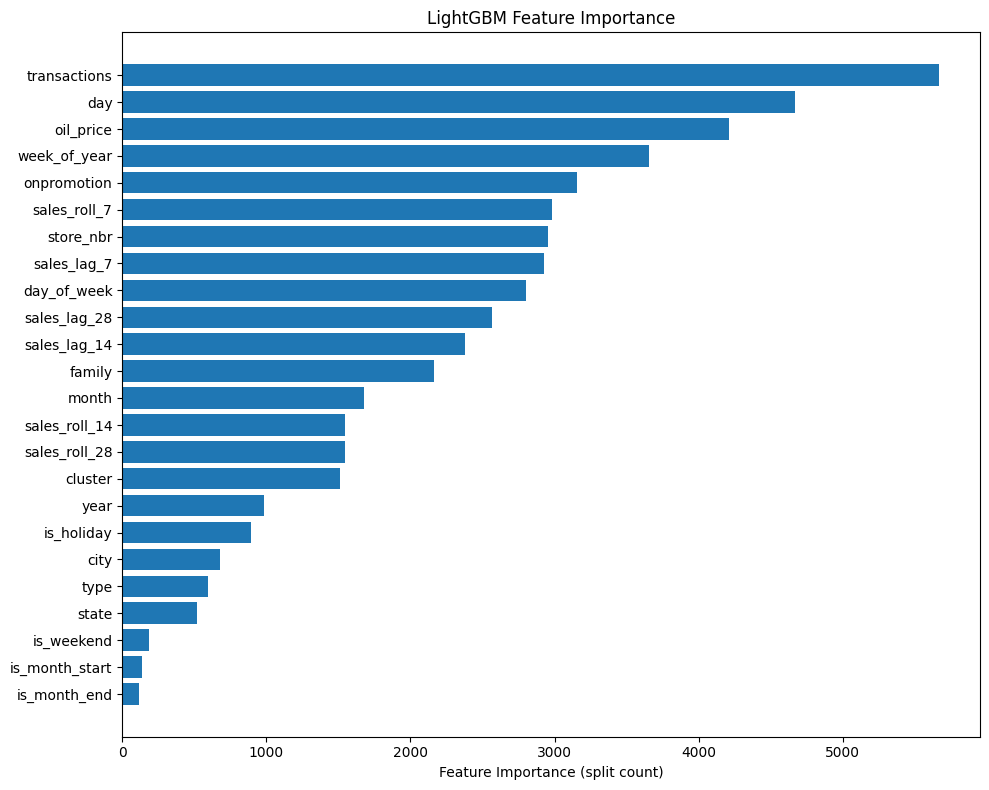


Top 10 features:
     feature  importance
transactions        5669
         day        4666
   oil_price        4211
week_of_year        3654
 onpromotion        3154
sales_roll_7        2982
   store_nbr        2952
 sales_lag_7        2925
 day_of_week        2801
sales_lag_28        2569


In [13]:
y_pred_val = model.predict(X_val).clip(0)
rmsle = np.sqrt(mean_squared_log_error(y_val.clip(0), y_pred_val))

print(f'Validation RMSLE: {rmsle:.4f}')
print('(Lower is better | Kaggle competition metric)')

imp_df = pd.DataFrame({
    'feature':    feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 8))
plt.barh(range(len(imp_df)), imp_df['importance'])
plt.yticks(range(len(imp_df)), imp_df['feature'])
plt.xlabel('Feature Importance (split count)')
plt.title('LightGBM Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print('\nTop 10 features:')
print(imp_df.head(10).to_string(index=False))

---
## 6. Predict & Submit

We combine training sales history with test dates to compute proper lag features for the 15-day prediction window, then save `submission.csv`.

In [17]:
# Ensure categorical columns are int — re-encode in-place if corrupted by a previous run
for col in cat_cols:
    if test[col].dtype == object:
        if 'encoders' in dir() and col in encoders:
            test[col] = encoders[col].transform(test[col].astype(str))
        else:
            # Fallback: fit a fresh encoder on test values.
            # LabelEncoder assigns ints alphabetically, so the mapping is identical
            # to the one used during training as long as every category is present in test
            # (guaranteed for this dataset: all 33 families appear in both splits).
            enc = LabelEncoder()
            enc.fit(test[col].astype(str))
            test[col] = enc.transform(test[col].astype(str))

# Compute proper lag features for test by appending test dates to training history
# train['family'] is already label-encoded (int), so combined stays numeric
test_placeholders = test[['date', 'store_nbr', 'family']].copy()
test_placeholders['sales'] = np.nan

combined = (pd.concat([train[['date', 'store_nbr', 'family', 'sales']], test_placeholders], ignore_index=True)
              .sort_values(['store_nbr', 'family', 'date'])
              .reset_index(drop=True))

lag_feature_cols = []
grp = combined.groupby(['store_nbr', 'family'])['sales']
for lag in [7, 14, 28]:
    col = f'sales_lag_{lag}'
    combined[col] = grp.shift(lag)
    lag_feature_cols.append(col)
for window in [7, 14, 28]:
    col = f'sales_roll_{window}'
    combined[col] = grp.shift(1).rolling(window).mean().reset_index(0, drop=True)
    lag_feature_cols.append(col)

test_lags = (combined[combined['date'] >= test['date'].min()]
             [['date', 'store_nbr', 'family'] + lag_feature_cols])

test = test.drop(columns=[c for c in lag_feature_cols if c in test.columns], errors='ignore')
test = test.merge(test_lags, on=['date', 'store_nbr', 'family'], how='left')

X_test     = test[feature_cols]
test_preds = model.predict(X_test).clip(0)

submission = pd.DataFrame({'id': test['id'], 'sales': test_preds})
submission.to_csv('submission.csv', index=False)

print('submission.csv saved!')
print(f'Predictions — min: {test_preds.min():.2f}, max: {test_preds.max():.2f}, mean: {test_preds.mean():.2f}')
print()
print('=' * 55)
print('PIPELINE SUMMARY')
print('=' * 55)
print(f'Dataset      : {len(train):,} train rows | {len(test):,} test rows')
print(f'Features used: {len(feature_cols)}')
print(f'Best LGB iter: {model.best_iteration_}')
print(f'Val RMSLE    : {rmsle:.4f}')
print()
print('Top 5 features by importance:')
for _, row in imp_df.head(5).iterrows():
    print(f'  {row["feature"]:30s}  {row["importance"]}')
print()
print('Output: submission.csv')
submission.head(10)

submission.csv saved!
Predictions — min: 0.00, max: 8438.35, mean: 419.86

PIPELINE SUMMARY
Dataset      : 2,950,992 train rows | 28,512 test rows
Features used: 24
Best LGB iter: 802
Val RMSLE    : 0.5864

Top 5 features by importance:
  transactions                    5669
  day                             4666
  oil_price                       4211
  week_of_year                    3654
  onpromotion                     3154

Output: submission.csv


,id,sales
0,3000888,0.000000
1,3000889,0.000000
2,3000890,739.335177
3,3000891,457.474441
4,3000892,0.000000
5,3000893,96.469842
6,3000894,31.625212
7,3000895,1849.806400
8,3000896,803.651524
9,3000897,35.603282
